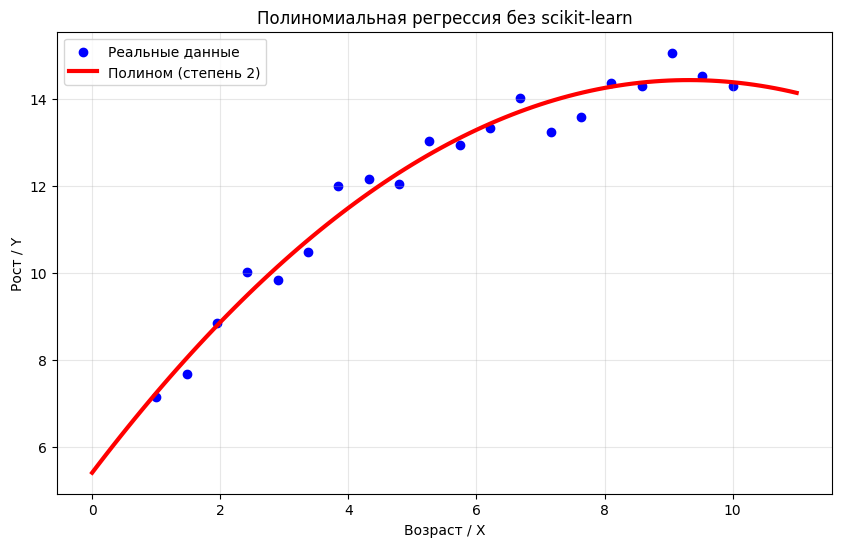

Коэффициенты полинома: [ 5.39900602  1.93997326 -0.10409722]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Генерируем данные (те же самые)
np.random.seed(42)
X = np.linspace(1, 10, 20)                # Массив X (возраст)
y = 2 * X - 0.1 * (X ** 2) + 5 + np.random.normal(0, 0.5, 20) # Целевая переменная (рост)

# Степень полинома (например, 2 = квадрат)
degree = 2

# 2. ВРУЧНУЮ создаем матрицу признаков (Design Matrix)
# Нам нужно превратить [X] в матрицу с колонками: [1, X, X^2]
# Это аналог PolynomialFeatures из sklearn
X_poly = np.zeros((len(X), degree + 1))   # Создаем пустую матрицу
for i in range(degree + 1):
    X_poly[:, i] = X ** i                 # Заполняем колонки: X^0, X^1, X^2...

# 3. Решаем уравнение методом наименьших квадратов (вручную)
# Формула: w = (X^T * X)^(-1) * X^T * y
# @ — это оператор умножения матриц в numpy
XTX = X_poly.T @ X_poly                    # (X транспонированная * X)
XTX_inv = np.linalg.inv(XTX)               # Обратная матрица
XTY = X_poly.T @ y                         # (X транспонированная * y)
w = XTX_inv @ XTY                          # Получаем веса (коэффициенты)

# 4. Делаем предсказание для красивой линии (100 точек)
X_plot = np.linspace(0, 11, 100)          # Плавный ряд чисел
X_plot_poly = np.zeros((len(X_plot), degree + 1))
for i in range(degree + 1):
    X_plot_poly[:, i] = X_plot ** i

# Умножаем матрицу полиномов на найденные веса, чтобы получить предсказания
y_pred = X_plot_poly @ w                  

# 5. Визуализация
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Реальные данные')
plt.plot(X_plot, y_pred, color='red', linewidth=3, label=f'Полином (степень {degree})')
plt.title('Полиномиальная регрессия без scikit-learn')
plt.xlabel('Возраст / X')
plt.ylabel('Рост / Y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Выведем полученные коэффициенты (w0 + w1*X + w2*X^2...)
print("Коэффициенты полинома:", w)